In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.python.keras.regularizers import l1_l2

In [112]:
data=pd.read_csv('/home/hammadali08/Vidoes/CSV file/Diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [113]:
x1=data.iloc[:,:-1]
y1=data['Outcome']

In [114]:
from imblearn.over_sampling import RandomOverSampler
ru=RandomOverSampler()

In [115]:
x,y=ru.fit_resample(x1,y1)
x.shape

(1000, 8)

In [116]:
from sklearn.preprocessing import StandardScaler

In [117]:
ss=StandardScaler()
ss.fit(x)

StandardScaler()

In [118]:
x=pd.DataFrame(ss.transform(x),columns=x.columns)
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.574871,0.698557,0.138409,0.860472,-0.697703,0.100322,0.382798,1.392309
1,-0.882712,-1.225590,-0.162698,0.501018,-0.697703,-0.771179,-0.393588,-0.250176
2,1.157904,1.767528,-0.263067,-1.236340,-0.697703,-1.182029,0.509382,-0.163730
3,-0.882712,-1.103422,-0.162698,0.141565,0.119361,-0.584429,-0.911179,-1.114643
4,-1.174228,0.362595,-1.467497,0.860472,0.762581,1.283074,5.055177,-0.077283
...,...,...,...,...,...,...,...,...
995,-0.299679,0.118259,1.142100,1.699196,0.649583,0.448923,1.342028,-0.163730
996,-0.882712,1.706444,-0.263067,0.560927,0.866888,0.162572,-0.458287,0.354950
997,0.283354,-0.400956,-0.162698,-1.236340,-0.697703,0.623223,-0.646757,0.614290
998,2.032453,0.393137,0.238778,0.321291,0.553969,0.411573,0.185888,1.392309


In [119]:
from sklearn.model_selection import train_test_split

In [120]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [121]:
import tensorflow as tf

In [122]:
from keras.models import Sequential
from keras.callbacks import EarlyStopping    # for avoiding Overfiting
from keras.regularizers import l1_l2           # Regularization to avoid Overfittig
from keras.layers import Dense,BatchNormalization,Dropout
from keras.losses import mean_absolute_error

In [123]:
sq=Sequential()

In [124]:
sq.add((Dense(8,activation='relu',kernel_regularizer=l1_l2()))) # Kernel Regularizer to avoid Overfitting
sq.add(BatchNormalization())                                    # It is used for avoid Overfitting and can be put for every layer
sq.add(Dense(7,activation='relu'))
sq.add(BatchNormalization())
sq.add(Dense(6,activation='relu'))
sq.add(Dropout(0.3))                                            # used to avoid overfitting(this basically train the only given percentage of nodes)
sq.add(Dense(5,activation='relu'))
sq.add(BatchNormalization())                                      # This is also used to avoid "Gradient Descent Problem"
sq.add(Dense(3,activation='relu'))
sq.add(Dropout(0.4))  #Dropout works best for avoiding Overfitting
sq.add(Dense(1,activation='sigmoid'))

In [125]:
sq.compile(optimizer='sgd',loss='mean_absolute_error',metrics=['accuracy'])

In [126]:
sq.fit(x_train,y_train,epochs=55,batch_size=1,validation_data=(x_test,y_test),callbacks=EarlyStopping())
# Validation data is for getting accuracy and loss of Test data
# Call back is used for avoiding Overfitting
# If the value of LOSS does not reduce with Epochs, It means it have Gradient Descent Problem

Epoch 1/55
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4675 - loss: 0.5003 - val_accuracy: 0.4950 - val_loss: 0.5050
Epoch 2/55
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4538 - loss: 0.5003 - val_accuracy: 0.4950 - val_loss: 0.5050


In [127]:
prd_y=sq.predict(x_train)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [128]:
prd_y_data=[]
for i in prd_y:
    if i>=0.5:
        prd_y_data.append(1)
    else:
        prd_y_data.append(0)

In [129]:
prd=sq.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [130]:
prd_data=[]
for i in prd:
    if i>=0.5:
        prd_data.append(1)
    else:
        prd_data.append(0)


In [131]:
from sklearn.metrics import confusion_matrix

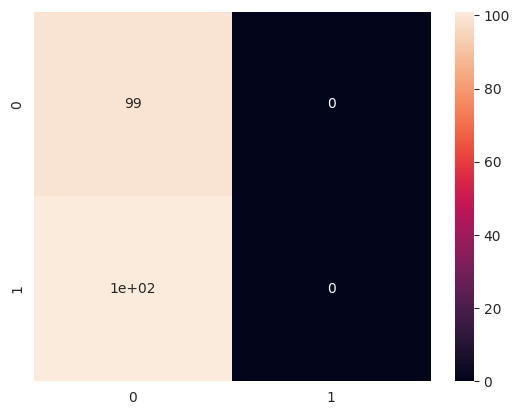

In [132]:
sns.heatmap(confusion_matrix(y_test,prd_data),annot=True)
plt.show()

In [133]:
from sklearn.metrics import accuracy_score

In [134]:
accuracy_score(y_test,prd_data)

0.495

In [135]:
accuracy_score(y_train,prd_y_data)

0.50125

In [136]:
sq.history.history     # Validation data was used up there to get the val_accuracy(test data accuracy)

{'accuracy': [0.4675000011920929, 0.45375001430511475],
 'loss': [0.5003110766410828, 0.5003077983856201],
 'val_accuracy': [0.4950000047683716, 0.4950000047683716],
 'val_loss': [0.5049999952316284, 0.5049999952316284]}

In [137]:
train_accuracy=sq.history.history['accuracy']
test_accuracy=sq.history.history['val_accuracy']

This basically shows the Overfitting

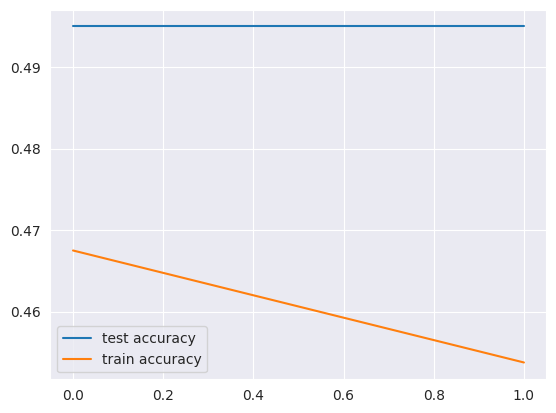

In [138]:
plt.plot(test_accuracy,label='test accuracy')
plt.plot(train_accuracy,label='train accuracy')
plt.legend()
plt.show()

In [139]:
# After model is compiled and trained
weights, biases = sq.layers[0].get_weights()
pd.DataFrame(weights)

,0,1,2,3,4,5,6,7
0,0.201221,0.538909,-0.157105,0.520844,-0.247552,-0.462400,0.569072,0.610414
1,0.289713,0.185585,0.602659,0.382990,0.523081,-0.317981,-0.186179,0.383056
2,0.473014,-0.562933,-0.508231,0.595579,0.209169,0.013978,-0.101297,0.483771
3,-0.561350,-0.179792,-0.560221,0.544340,0.513377,-0.529196,-0.118756,0.055297
4,-0.199516,-0.533906,-0.115251,0.195063,0.213492,-0.417685,-0.388146,0.557921
5,0.036856,-0.034011,0.241100,-0.092380,0.304475,0.375696,-0.412995,-0.582776
6,-0.114254,-0.265776,0.317907,-0.479437,-0.298612,0.539338,0.505142,-0.499111
7,0.405684,0.180546,-0.236820,-0.396198,-0.570077,0.166376,0.200038,0.284612


In [140]:
optimizer = sq.optimizer
print(optimizer.learning_rate.numpy())

0.01
